# 🌦️ KisanSaathi — Weather Tool + LLM Test (Fixed)

Tests the **full pipeline** in isolation:
```
START → llm_node → [LLM calls get_weather?]
                        YES → tool_node → llm_node → END
                        NO  → END
```

**Fixes applied vs original:**
1. `asyncpg` + Neon SSL fix — strip `sslmode` from DSN, pass `ssl=True` explicitly
2. `channel_binding=require` stripped (was already done, kept)
3. Removed double-timeout (`asyncio.wait_for` + asyncpg `timeout` conflict)
4. `err_detail` always populated — `f"{type(e).__name__}: {e}"` unconditionally
5. Standalone tool test cell — test DB + Open-Meteo *before* running the graph
6. System prompt tells LLM **not to retry** on tool error
7. `tool_call_count` guard in graph — hard-stops after 2 tool calls max
8. Cell 9 pass/fail check validates **actual forecast data**, not just ToolMessage existence

## Cell 0 — Install Dependencies

In [1]:
import sys, subprocess
pkgs = [
    "httpx", "asyncpg", "python-dotenv",
    "langgraph>=0.2", "langchain", "langchain-groq",
    "langchain-core", "typing_extensions"
]
r = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q"] + pkgs,
    capture_output=True, text=True
)
print("✅ Dependencies ready" if r.returncode == 0 else f"❌ pip error:\n{r.stderr}")

✅ Dependencies ready


## Cell 1 — Imports & Config

In [2]:
import os, sys, uuid, json, asyncio, logging, traceback
import urllib.parse as _up
from pathlib import Path
from contextlib import asynccontextmanager
from typing import Annotated

import httpx
import asyncpg
from dotenv import load_dotenv
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from langchain_core.tools import tool
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, END, START
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from typing import TypedDict

# ── Find .env walking up from cwd ────────────────────────────────────────────
BACKEND_ROOT = Path.cwd()
for _ in range(6):
    if (BACKEND_ROOT / ".env").exists():
        break
    BACKEND_ROOT = BACKEND_ROOT.parent

load_dotenv(BACKEND_ROOT / ".env", override=True)
logging.basicConfig(level=logging.WARNING)   # suppress noisy INFO logs

GROQ_API_KEY = os.getenv("GROQ_API_KEY") or os.getenv("GROK_API_KEY", "")
# llama-3.1-8b-instant is fine for tool-use tests and has a higher free quota
GROQ_MODEL   = os.getenv("GROQ_MODEL", "llama-3.1-8b-instant")
DATABASE_URL = os.getenv("DATABASE_URL", "")

# ── 👇 Put your real farmer_id here ──────────────────────────────────────────
FARMER_ID = "30156622-0b76-43e6-8eef-33bb6f7eae0c"   # replace with actual UUID

print(f"🔑 GROQ_API_KEY : {'✅ SET' if GROQ_API_KEY else '❌ MISSING — add to .env'}")
print(f"🤖 GROQ_MODEL   : {GROQ_MODEL}")
print(f"🗄️  DATABASE_URL : {'✅ SET' if DATABASE_URL else '❌ MISSING — add to .env'}")
print(f"👤 FARMER_ID    : {FARMER_ID}")

🔑 GROQ_API_KEY : ✅ SET
🤖 GROQ_MODEL   : llama-3.1-8b-instant
🗄️  DATABASE_URL : ✅ SET
👤 FARMER_ID    : 30156622-0b76-43e6-8eef-33bb6f7eae0c


## Cell 2 — DB Helper

**Key fix:** asyncpg does not reliably parse `sslmode=require` or `channel_binding=require`
from a connection string. We strip BOTH from the DSN and pass `ssl=True` explicitly.

In [3]:
DB_CONNECT_TIMEOUT = 10.0   # seconds


def _clean_dsn(raw_dsn: str) -> str:
    """
    Strips query parameters that asyncpg either doesn't support or
    handles through its own keyword arguments:
      - channel_binding : not supported by asyncpg at all
      - sslmode         : asyncpg ignores this; use ssl= kwarg instead
    """
    parsed = _up.urlparse(raw_dsn)
    qs = _up.parse_qs(parsed.query, keep_blank_values=True)
    qs.pop("channel_binding", None)
    qs.pop("sslmode", None)          # ← FIX: must be removed; asyncpg ignores it
    return parsed._replace(query=_up.urlencode(qs, doseq=True)).geturl()


async def _init_conn(conn: asyncpg.Connection) -> None:
    """Register JSON/JSONB codecs on every new connection."""
    for codec in ("jsonb", "json"):
        await conn.set_type_codec(
            codec,
            encoder=json.dumps,
            decoder=json.loads,
            schema="pg_catalog",
            format="text",
        )


@asynccontextmanager
async def get_db_connection():
    """
    Async context manager that opens a single asyncpg connection to Neon.

    ssl=True   → tells asyncpg to use TLS (required by Neon)
    timeout    → asyncpg's own built-in; no asyncio.wait_for wrapper needed
    """
    raw_dsn = os.getenv("DATABASE_URL")
    if not raw_dsn:
        raise RuntimeError("DATABASE_URL is not set in .env")

    clean = _clean_dsn(raw_dsn)

    # ── FIX: ssl=True instead of relying on sslmode in DSN ────────────────────
    # ── FIX: single timeout in asyncpg.connect(), no asyncio.wait_for wrapper ─
    conn = await asyncpg.connect(
        dsn=clean,
        ssl=True,                      # ← THE KEY FIX for Neon
        timeout=DB_CONNECT_TIMEOUT,
    )
    try:
        await _init_conn(conn)
        yield conn
    finally:
        await conn.close()


# ── Smoke test: run SELECT 1 and show what tables the farmer has ──────────────
async def _smoke_test():
    print("🔄 Testing DB connection...")
    try:
        async with get_db_connection() as conn:
            val = await conn.fetchval("SELECT 1")
            print(f"✅ DB connection OK  (SELECT 1 = {val})")

            # Check if FARMER_ID exists in farmers table
            try:
                fid = uuid.UUID(FARMER_ID)
            except ValueError:
                print("⚠️  FARMER_ID is not a valid UUID — update Cell 1")
                return

            farmer = await conn.fetchrow(
                "SELECT name, dist_name, state_name FROM farmers WHERE id = $1", fid
            )
            if farmer:
                print(f"✅ Farmer found     : {farmer['name']} / {farmer['dist_name']}, {farmer['state_name']}")
            else:
                print(f"⚠️  Farmer ID not found in DB. Run POST /farmers/register first.")
                return

            farm = await conn.fetchrow(
                """
                SELECT id, center_lat, center_lon, city_name, state_name, area_hectares
                FROM   farm_fields
                WHERE  farmer_id = $1
                ORDER  BY created_at DESC LIMIT 1
                """,
                fid,
            )
            if farm:
                print(f"✅ Farm found       : lat={farm['center_lat']}, lon={farm['center_lon']}")
                print(f"   Location         : {farm['city_name']}, {farm['state_name']}  ({farm['area_hectares']} ha)")
            else:
                print("⚠️  No farm_fields row for this farmer. Run POST /farm/register first.")

    except Exception as exc:
        # ── FIX: always print full exception details ──────────────────────────
        print(f"❌ DB connection FAILED")
        print(f"   Exception type : {type(exc).__name__}")
        print(f"   Message        : {exc}")
        traceback.print_exc()


await _smoke_test()
print("\n✅ DB helper ready")

🔄 Testing DB connection...
✅ DB connection OK  (SELECT 1 = 1)
✅ Farmer found     : Ramesh Kumar / ludhiana, Punjab
✅ Farm found       : lat=30.735, lon=76.785
   Location         : Chandigarh, Chandigarh  (1.4 ha)

✅ DB helper ready


## Cell 3 — Weather Tool Definition

In [4]:
OPEN_METEO_URL = "https://api.open-meteo.com/v1/forecast"


@tool
async def get_weather(farmer_id: str) -> dict:
    """
    Fetches 3-day weather forecast for the farmer's registered farm location.
    Looks up the farm's GPS coordinates from the database, then calls
    the Open-Meteo API (free, no key needed).
    Call this when the farmer asks about rain, temperature, drought risk,
    or whether to irrigate their field.
    Args:
        farmer_id: UUID string of the farmer (from /farmers/register)
    """
    print(f"\n   🔧 [get_weather tool] called with farmer_id={farmer_id}")

    # ── Step 1: validate UUID ─────────────────────────────────────────────────
    try:
        fid = uuid.UUID(str(farmer_id))
    except (ValueError, AttributeError):
        return {"error": True, "message": f"Invalid farmer_id format: '{farmer_id}'"}

    # ── Step 2: fetch lat/lon from DB ─────────────────────────────────────────
    try:
        async with get_db_connection() as conn:
            farm = await conn.fetchrow(
                """
                SELECT center_lat, center_lon, city_name, state_name
                FROM   farm_fields
                WHERE  farmer_id = $1
                ORDER  BY created_at DESC
                LIMIT  1
                """,
                fid,
            )
    except Exception as e:
        # ── FIX: always format both type and message ─────────────────────────
        err_detail = f"{type(e).__name__}: {e}"
        print(f"   ❌ DB error: {err_detail}")
        traceback.print_exc()
        return {"error": True, "message": f"DB connection error: {err_detail}"}

    if not farm:
        return {
            "error": True,
            "message": (
                f"No farm registered for farmer_id '{farmer_id}'. "
                "Ask the farmer to register their farm via POST /farm/register."
            )
        }

    lat = farm["center_lat"]
    lon = farm["center_lon"]

    if lat is None or lon is None:
        return {"error": True, "message": "Farm has no GPS coordinates stored."}

    location = ", ".join(filter(None, [farm.get("city_name"), farm.get("state_name")])) \
               or f"{lat:.4f}°N, {lon:.4f}°E"
    print(f"   📍 Farm location: {location}  (lat={lat}, lon={lon})")

    # ── Step 3: call Open-Meteo ───────────────────────────────────────────────
    try:
        async with httpx.AsyncClient(timeout=15.0) as client:
            resp = await client.get(
                OPEN_METEO_URL,
                params={
                    "latitude":    lat,
                    "longitude":   lon,
                    "daily": (
                        "temperature_2m_max,"
                        "temperature_2m_min,"
                        "precipitation_sum,"
                        "precipitation_probability_max,"
                        "windspeed_10m_max"
                    ),
                    "forecast_days": 3,
                    "timezone": "Asia/Kolkata",
                },
            )
    except httpx.RequestError as e:
        return {"error": True, "message": f"Open-Meteo network error: {type(e).__name__}: {e}"}

    if resp.status_code != 200:
        return {"error": True, "message": f"Open-Meteo HTTP {resp.status_code}: {resp.text[:200]}"}

    # ── Step 4: parse response ────────────────────────────────────────────────
    data  = resp.json()
    daily = data.get("daily", {})
    dates = daily.get("time", [])
    tmax  = daily.get("temperature_2m_max", [])
    tmin  = daily.get("temperature_2m_min", [])
    rain  = daily.get("precipitation_sum", [])
    prob  = daily.get("precipitation_probability_max", [])
    wind  = daily.get("windspeed_10m_max", [])

    forecast = [
        {
            "date":         dates[i],
            "temp_max_c":   round(tmax[i], 1)      if i < len(tmax) else None,
            "temp_min_c":   round(tmin[i], 1)      if i < len(tmin) else None,
            "rain_mm":      round(rain[i] or 0, 1) if i < len(rain) else 0,
            "rain_prob_pct": prob[i]               if i < len(prob) else None,
            "wind_kmh":     round(wind[i], 1)      if i < len(wind) else None,
        }
        for i in range(len(dates))
    ]

    # ── Step 5: irrigation advice ─────────────────────────────────────────────
    total_rain = sum(f["rain_mm"] for f in forecast)
    if total_rain >= 20:
        advice = "Irrigation rokein — kaafi barish aane wali hai."
    elif total_rain >= 8:
        advice = "Irrigation kam karein — thodi barish expected hai."
    else:
        advice = "Irrigation karein — agle 3 din mein barish nahi dikh rahi."

    print(f"   ✅ Open-Meteo OK — today max={tmax[0] if tmax else '?'}°C, total_rain_3d={total_rain:.1f}mm")

    return {
        "error":                False,
        "location":             location,
        "coordinates":          {"latitude": lat, "longitude": lon},
        "forecast_3_days":      forecast,
        "total_rain_next_3d_mm": round(total_rain, 1),
        "irrigation_advice":    advice,
    }


print(f"✅ get_weather tool defined  (name='{get_weather.name}')")

✅ get_weather tool defined  (name='get_weather')


## Cell 4 — 🧪 Standalone Tool Test (Isolate DB + Open-Meteo)

**Run this BEFORE the graph.** If it fails here, the issue is in the tool, not LangGraph.
Fix any error here first, then continue to Cell 5.

In [5]:
print(f"🧪 Running standalone tool test for farmer_id: {FARMER_ID}")
print("-" * 55)

# Call the tool directly — bypasses LangGraph entirely
raw_result = await get_weather.ainvoke({"farmer_id": FARMER_ID})

print("\n📦 Raw tool output:")
print(json.dumps(raw_result, indent=2, ensure_ascii=False))

print()
if raw_result.get("error"):
    print(f"❌ Tool returned error: {raw_result['message']}")
    print("   → Fix the error above BEFORE running the graph (Cell 6+)")
else:
    fc = raw_result.get("forecast_3_days", [])
    print(f"✅ Tool works correctly!")
    print(f"   Location  : {raw_result.get('location')}")
    print(f"   Total rain: {raw_result.get('total_rain_next_3d_mm')} mm")
    print(f"   Advice    : {raw_result.get('irrigation_advice')}")
    print("   Forecast  :")
    for day in fc:
        print(f"     {day['date']}: max={day['temp_max_c']}°C  "
              f"rain={day['rain_mm']}mm ({day['rain_prob_pct']}%)  "
              f"wind={day['wind_kmh']} km/h")

🧪 Running standalone tool test for farmer_id: 30156622-0b76-43e6-8eef-33bb6f7eae0c
-------------------------------------------------------

   🔧 [get_weather tool] called with farmer_id=30156622-0b76-43e6-8eef-33bb6f7eae0c
   📍 Farm location: Chandigarh, Chandigarh  (lat=30.735, lon=76.785)
   ✅ Open-Meteo OK — today max=39.6°C, total_rain_3d=0.0mm

📦 Raw tool output:
{
  "error": false,
  "location": "Chandigarh, Chandigarh",
  "coordinates": {
    "latitude": 30.735,
    "longitude": 76.785
  },
  "forecast_3_days": [
    {
      "date": "2026-04-24",
      "temp_max_c": 39.6,
      "temp_min_c": 24.1,
      "rain_mm": 0,
      "rain_prob_pct": 3,
      "wind_kmh": 12.4
    },
    {
      "date": "2026-04-25",
      "temp_max_c": 40.0,
      "temp_min_c": 24.8,
      "rain_mm": 0,
      "rain_prob_pct": 0,
      "wind_kmh": 15.6
    },
    {
      "date": "2026-04-26",
      "temp_max_c": 39.8,
      "temp_min_c": 22.5,
      "rain_mm": 0,
      "rain_prob_pct": 0,
      "wind_kmh": 

## Cell 5 — LangGraph Agent (LLM + Nodes + Graph)

In [6]:
# ── State ─────────────────────────────────────────────────────────────────────
class AgentState(TypedDict):
    messages:        Annotated[list, add_messages]
    # Safety counter — prevents infinite LLM ↔ tool loops
    # Incremented in llm_node each time the LLM fires a tool call.
    # should_use_tools forces END when this reaches MAX_TOOL_CALLS.
    tool_call_count: int


MAX_TOOL_CALLS = 2   # LLM allowed at most 2 tool calls per conversation turn


# ── LLM factory ───────────────────────────────────────────────────────────────
def _make_llm() -> ChatGroq:
    """Creates a fresh ChatGroq client from current env vars."""
    if not GROQ_API_KEY:
        raise RuntimeError("GROQ_API_KEY missing — add to .env and re-run Cell 1")
    return ChatGroq(
        model=GROQ_MODEL,
        api_key=GROQ_API_KEY,
        temperature=0.1,
        max_tokens=512,
        request_timeout=30,
    )


# ── Nodes ──────────────────────────────────────────────────────────────────────
async def llm_node(state: AgentState) -> dict:
    """
    Calls the LLM with all bound tools.
    Increments tool_call_count when the LLM fires a tool call.
    """
    print("\n🟣 [llm_node] — calling LLM…")

    llm_with_tools = _make_llm().bind_tools([get_weather])

    try:
        response = await llm_with_tools.ainvoke(state["messages"])
    except Exception as exc:
        print(f"   ❌ LLM error: {type(exc).__name__}: {exc}")
        response = AIMessage(
            content=(
                "Maaf karo — abhi LLM se connection mein problem aa rahi hai. "
                f"({type(exc).__name__})"
            )
        )

    current_count = state.get("tool_call_count", 0)

    if getattr(response, "tool_calls", []):
        print(f"   🔀 LLM wants to call tools: {[tc['name'] for tc in response.tool_calls]}")
        new_count = current_count + 1
    else:
        preview = str(response.content)[:120]
        print(f"   💬 LLM final answer: {preview}{'…' if len(str(response.content)) > 120 else ''}")
        new_count = current_count

    return {
        "messages":        [response],
        "tool_call_count": new_count,
    }


# ── Conditional edge ──────────────────────────────────────────────────────────
def should_use_tools(state: AgentState) -> str:
    """
    Route to 'tool_node' if LLM produced tool_calls AND we haven't hit the cap.
    Route to END otherwise.
    """
    # ── FIX: hard-stop after MAX_TOOL_CALLS to prevent infinite retry loops ──
    if state.get("tool_call_count", 0) >= MAX_TOOL_CALLS:
        print(f"   ⛔ MAX_TOOL_CALLS ({MAX_TOOL_CALLS}) reached — forcing END")
        return END

    last = state["messages"][-1]
    if isinstance(last, AIMessage) and getattr(last, "tool_calls", []):
        return "tool_node"
    return END


# ── Build graph ────────────────────────────────────────────────────────────────
tool_node = ToolNode([get_weather])

builder = StateGraph(AgentState)
builder.add_node("llm_node",  llm_node)
builder.add_node("tool_node", tool_node)

builder.add_edge(START, "llm_node")
builder.add_conditional_edges(
    "llm_node",
    should_use_tools,
    {"tool_node": "tool_node", END: END},
)
builder.add_edge("tool_node", "llm_node")   # after tool result → back to LLM for final answer

graph = builder.compile()

print("✅ LangGraph compiled successfully")
print("   Nodes:", list(graph.get_graph().nodes.keys()))
print("   Edges:", [(e.source, e.target) for e in graph.get_graph().edges])

✅ LangGraph compiled successfully
   Nodes: ['__start__', 'llm_node', 'tool_node', '__end__']
   Edges: [('__start__', 'llm_node'), ('llm_node', '__end__'), ('llm_node', 'tool_node'), ('tool_node', 'llm_node')]


## Cell 6 — (Optional) Visualise Graph

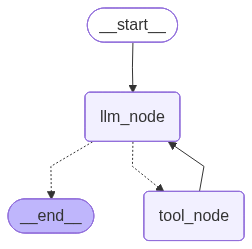

In [7]:
try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"⚠️  Graph viz skipped: {e}")

## Cell 7 — ⚙️ Set Farmer ID & User Question

In [8]:
# FARMER_ID is already set in Cell 1 — change it there if needed

USER_QUESTION = (
    f"Meri khet mein agle 3 din barish hogi? "
    f"Kya mujhe irrigation karni chahiye? "
    f"farmer_id: {FARMER_ID}"
)

# ── FIX: System prompt explicitly tells LLM not to retry on tool error ────────
SYSTEM_PROMPT = (
    "You are KisanSaathi (किसान साथी), an AI assistant for Indian farmers.\n"
    "You have access to a get_weather tool that fetches real weather data "
    "for a farmer's field using their farmer_id.\n"
    "\n"
    "RULES — follow these exactly:\n"
    "1. When the farmer asks about rain, temperature, drought, or irrigation: "
    "   call get_weather once with their farmer_id.\n"
    "2. If the tool returns {\"error\": true}: "
    "   do NOT call the tool again. "
    "   Immediately apologise and give a brief general farming tip.\n"
    "3. After you have the tool result, give your final answer. "
    "   Do NOT call any tool a second time.\n"
    "4. Reply in simple Hinglish (Hindi + English mix). Max 100 words."
)

print(f"📌 farmer_id    : {FARMER_ID}")
print(f"💬 User question: {USER_QUESTION}")

📌 farmer_id    : 30156622-0b76-43e6-8eef-33bb6f7eae0c
💬 User question: Meri khet mein agle 3 din barish hogi? Kya mujhe irrigation karni chahiye? farmer_id: 30156622-0b76-43e6-8eef-33bb6f7eae0c


## Cell 8 — 🚀 Run the Graph

In [9]:
initial_state: AgentState = {
    "messages": [
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content=USER_QUESTION),
    ],
    "tool_call_count": 0,   # reset counter for this run
}

print("🚀 Invoking LangGraph…")
print("─" * 60)

result = await graph.ainvoke(
    initial_state,
    config={"recursion_limit": 20},   # safety net
)

print("─" * 60)
print("🏁 Graph finished.")

🚀 Invoking LangGraph…
────────────────────────────────────────────────────────────

🟣 [llm_node] — calling LLM…
   🔀 LLM wants to call tools: ['get_weather']

   🔧 [get_weather tool] called with farmer_id=30156622-0b76-43e6-8eef-33bb6f7eae0c
   📍 Farm location: Chandigarh, Chandigarh  (lat=30.735, lon=76.785)

🟣 [llm_node] — calling LLM…
   💬 LLM final answer: Koi baat nahin, agar aapke khet mein barish nahin hogi, to aapko irrigation karni hogi. Lekin agar aapke paas pani ki ka…
────────────────────────────────────────────────────────────
🏁 Graph finished.


## Cell 9 — 📊 Conversation Trace

In [10]:
print("═" * 60)
print("  CONVERSATION TRACE")
print("═" * 60)

for msg in result["messages"]:
    if isinstance(msg, SystemMessage):
        continue   # skip system prompt in trace output

    elif isinstance(msg, HumanMessage):
        print(f"\n👨‍🌾 FARMER:\n{msg.content}")

    elif isinstance(msg, AIMessage):
        if getattr(msg, "tool_calls", []):
            for tc in msg.tool_calls:
                print(f"\n🔀 LLM calls tool → {tc['name']}({tc['args']})")
        elif msg.content:
            print(f"\n🤖 KISANSAATHI:\n{msg.content}")

    elif isinstance(msg, ToolMessage):
        try:
            data = json.loads(msg.content) if isinstance(msg.content, str) else msg.content
        except Exception:
            data = msg.content

        print(f"\n🔧 TOOL RESULT ({msg.name}):")
        if isinstance(data, dict) and data.get("error"):
            print(f"   ❌ Error: {data.get('message')}")
        elif isinstance(data, dict) and "forecast_3_days" in data:
            print(f"   Location  : {data.get('location')}")
            print(f"   Total rain: {data.get('total_rain_next_3d_mm')} mm")
            print(f"   Advice    : {data.get('irrigation_advice')}")
            print("   Forecast  :")
            for day in data["forecast_3_days"]:
                print(f"     {day['date']}: "
                      f"max={day['temp_max_c']}°C  "
                      f"rain={day['rain_mm']}mm ({day['rain_prob_pct']}%)  "
                      f"wind={day['wind_kmh']} km/h")
        else:
            print(f"   {data}")

print("\n" + "═" * 60)

════════════════════════════════════════════════════════════
  CONVERSATION TRACE
════════════════════════════════════════════════════════════

👨‍🌾 FARMER:
Meri khet mein agle 3 din barish hogi? Kya mujhe irrigation karni chahiye? farmer_id: 30156622-0b76-43e6-8eef-33bb6f7eae0c

🔀 LLM calls tool → get_weather({'farmer_id': '30156622-0b76-43e6-8eef-33bb6f7eae0c'})

🔧 TOOL RESULT (get_weather):
   ❌ Error: Open-Meteo network error: ConnectTimeout: 

🤖 KISANSAATHI:
Koi baat nahin, agar aapke khet mein barish nahin hogi, to aapko irrigation karni hogi. Lekin agar aapke paas pani ki kami hai, to aapko kuch aur sochne ki zaroorat hai. Aap apne khet mein rainwater harvesting kar sakte hain, jisse aapke paas pani ki kami nahin hogi.

════════════════════════════════════════════════════════════


## Cell 10 — ✅ Pass / Fail Check

**FIX vs original:** Now checks that the tool returned **actual forecast data** (not just that a ToolMessage exists).

In [12]:
msgs = result["messages"]

# Check 1: Did the LLM call the weather tool?
has_tool_call = any(
    isinstance(m, AIMessage) and getattr(m, "tool_calls", [])
    for m in msgs
)

# ── FIX: Check that the tool returned REAL data (forecast_3_days), not an error ──
tool_success = False
tool_error_msg = ""
for m in msgs:
    if isinstance(m, ToolMessage):
        try:
            data = json.loads(m.content) if isinstance(m.content, str) else m.content
            if isinstance(data, dict):
                if data.get("error"):
                    tool_error_msg = data.get("message", "unknown error")
                elif "forecast_3_days" in data:
                    tool_success = True
        except Exception:
            pass

# Check 3: Did the LLM produce a final answer (non-empty, no tool calls)?
final_ai = next(
    (m for m in reversed(msgs)
     if isinstance(m, AIMessage) and not getattr(m, "tool_calls", []) and m.content),
    None,
)

# Check 4: Did the LLM retry the tool unnecessarily?
tool_call_msgs = [m for m in msgs if isinstance(m, AIMessage) and getattr(m, "tool_calls", [])]
retried = len(tool_call_msgs) > 1

print("CHECKS")
print(f"  LLM called weather tool    : {'✅' if has_tool_call else '❌ — LLM never called the tool'}")
print(f"  Tool returned real data    : {'✅' if tool_success else f'❌ — {tool_error_msg or "no forecast data"}'}")
print(f"  LLM gave final answer      : {'✅' if final_ai else '❌ — no final AI message found'}")
print(f"  LLM did NOT retry on error : {'✅' if not retried else f'❌ — tool was called {len(tool_call_msgs)} times (should be 1)'}")

all_passed = has_tool_call and tool_success and final_ai and not retried
if all_passed:
    print("\n🎉 ALL CHECKS PASSED — LLM + Weather tool pipeline is working!")
else:
    print("\n⚠️  Some checks failed — review the trace in Cell 9.")
    if not tool_success and tool_error_msg:
        print(f"   Tool error was: {tool_error_msg}")
        print("   → Re-run Cell 4 (standalone tool test) to debug the DB/API issue.")

SyntaxError: f-string: unterminated string (69924157.py, line 37)